# Trigonometry and Vectors

Vectors are used throughout physics to describe quantities that have both a **magnitude** and a **direction**, such as displacement, velocity, acceleration and force.

Before working with vectors, we will briefly review the trigonometry needed to describe directions and vector components.

# 1. The Unit Circle

The **unit circle** is a circle of radius 1 centered at the origin:

$$
x^2+y^2=1.
$$

A point $P$ on the unit circle can be described by an angle $\theta$ measured counterclockwise from the positive $x$-axis.

Its coordinates are

$$
x=\cos\theta,\qquad y=\sin\theta.
$$

Therefore,

$$
P=(\cos\theta,\sin\theta).
$$

The unit circle gives a geometric meaning to sine and cosine.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def plot_unit_circle(theta_value, angle_unit):

    if angle_unit == 'Degrees':
        theta = np.deg2rad(theta_value)
        angle_text = rf"$\theta = {theta_value:.0f}^\circ$"
    else:
        theta = theta_value
        angle_text = rf"$\theta = {theta/np.pi:.2f}\pi\ \mathrm{{rad}}$"

    x = np.cos(theta)
    y = np.sin(theta)

    fig, ax = plt.subplots(figsize=(8, 7))

    # Unit circle
    phi = np.linspace(0, 2*np.pi, 500)
    ax.plot(np.cos(phi), np.sin(phi), 'k', lw=1.5)

    # Coordinate axes
    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.8)

    # Radius vector
    ax.arrow(
        0, 0, x, y,
        width=0.008,
        head_width=0.06,
        head_length=0.08,
        length_includes_head=True
    )

    # cos(theta) and sin(theta)
    ax.plot([0, x], [0, 0], lw=3)
    ax.plot([x, x], [0, y], lw=3)

    # Point on unit circle
    ax.plot(x, y, 'ko')
    ax.text(x + 0.05, y + 0.05, r'$P$')

    ax.text(
        x/2,
        -0.10 if y >= 0 else 0.10,
        r'$\cos\theta$',
        ha='center'
    )

    ax.text(
        x + 0.06,
        y/2,
        r'$\sin\theta$',
        va='center'
    )

    # Angle arc
    theta_arc = np.linspace(0, theta, 150)
    r_arc = 0.25
    ax.plot(
        r_arc*np.cos(theta_arc),
        r_arc*np.sin(theta_arc),
        'k'
    )

    ax.text(
        0.34*np.cos(theta/2),
        0.34*np.sin(theta/2),
        r'$\theta$'
    )

    # Tangent line x = 1
    ax.plot([1, 1], [-1.4, 1.4], 'k--', lw=1)

    if abs(x) > 1e-6:
        tan_theta = np.tan(theta)

        # Ray through P, extended toward x = 1
        # Plot beyond the visible window; fixed limits keep circle unchanged.
        scale = 2.5 * np.sign(x)
        ax.plot(
            [0, scale*x],
            [0, scale*y],
            lw=1,
            alpha=0.6
        )

        tan_visible = np.clip(tan_theta, -1.4, 1.4)
        ax.plot([1, 1], [0, tan_visible], lw=4)

        if abs(tan_theta) <= 1.4:
            ax.plot(1, tan_theta, 'ko')
            ax.text(
                1.05, tan_theta/2,
                r'$\tan\theta$',
                va='center'
            )
        else:
            ax.text(
                1.05, 1.10*np.sign(tan_theta),
                r'$\tan\theta$',
                va='center'
            )

        tan_text = f"{tan_theta:.3f}"
    else:
        tan_text = "undefined"

    info = (
        angle_text + "\n"
        rf"$\sin\theta = {y:.3f}$" "\n"
        rf"$\cos\theta = {x:.3f}$" "\n"
        rf"$\tan\theta = {tan_text}$"
    )

    ax.text(
        -1.32, 1.32,
        info,
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.85
        )
    )

    # Keep the view fixed even when tan(theta) becomes large
    ax.set_aspect('equal')
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.45, 1.45)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.grid(alpha=0.2)

    plt.show()
    plt.close(fig)


angle_unit = widgets.ToggleButtons(
    options=['Degrees', 'Radians'],
    value='Degrees',
    description='Angle:'
)

degree_slider = widgets.IntSlider(
    value=45,
    min=-90,
    max=360,
    step=5,
    description=r'$\theta$:',
    continuous_update=True
)

radian_slider = widgets.FloatSlider(
    value=np.pi/4,
    min=-np.pi/2,
    max=2*np.pi,
    step=np.pi/36,
    description=r'$\theta$:',
    continuous_update=True,
    readout_format='.2f'
)

slider_box = widgets.VBox([degree_slider])

def change_unit(change):
    if change['new'] == 'Degrees':
        degree_slider.value = int(round(np.rad2deg(radian_slider.value)))
        slider_box.children = [degree_slider]
    else:
        radian_slider.value = np.deg2rad(degree_slider.value)
        slider_box.children = [radian_slider]

angle_unit.observe(change_unit, names='value')

out = widgets.Output()

def redraw(*args):
    with out:
        out.clear_output(wait=True)

        if angle_unit.value == 'Degrees':
            plot_unit_circle(degree_slider.value, 'Degrees')
        else:
            plot_unit_circle(radian_slider.value, 'Radians')

degree_slider.observe(redraw, names='value')
radian_slider.observe(redraw, names='value')
angle_unit.observe(redraw, names='value')

display(angle_unit)
display(slider_box)
display(out)

redraw()

ToggleButtons(description='Angle:', options=('Degrees', 'Radians'), value='Degrees')

Output()

## Sine, cosine and tangent

For a right triangle,

$$
\sin\theta=\frac{\text{opposite}}{\text{hypotenuse}},
$$

$$
\cos\theta=\frac{\text{adjacent}}{\text{hypotenuse}},
$$

and

$$
\tan\theta=\frac{\text{opposite}}{\text{adjacent}}.
$$

Because on the unit circle the hypotenuse has length 1,

$$
x=\cos\theta,\qquad y=\sin\theta.
$$

Furthermore,

$$
\tan\theta=\frac{\sin\theta}{\cos\theta}
          =\frac{y}{x}.
$$

## Some important angles

| $\theta$ | $\sin\theta$ | $\cos\theta$ | $\tan\theta$ |
|---:|---:|---:|---:|
| $0^\circ$ | $0$ | $1$ | $0$ |
| $30^\circ$ | $\frac12$ | $\frac{\sqrt3}{2}$ | $\frac1{\sqrt3}$ |
| $45^\circ$ | $\frac1{\sqrt2}$ | $\frac1{\sqrt2}$ | $1$ |
| $60^\circ$ | $\frac{\sqrt3}{2}$ | $\frac12$ | $\sqrt3$ |
| $90^\circ$ | $1$ | $0$ | not defined |

Angles may be given in **degrees** or **radians**:

$$
180^\circ=\pi\ \mathrm{rad}.
$$

Thus,

$$
45^\circ=\frac{\pi}{4},\qquad
90^\circ=\frac{\pi}{2}.
$$

# In-class exercises: Trigonometry

### Exercise 1

A right triangle has a hypotenuse of $5\,\mathrm{m}$ and an angle of $30^\circ$.

Calculate the lengths of

1. the side adjacent to the angle,
2. the side opposite to the angle.

### Exercise 2

Evaluate without a calculator:

$$
\sin 45^\circ,\qquad
\cos 60^\circ,\qquad
\tan45^\circ.
$$

### Exercise 3

Convert:

1. $30^\circ$ to radians,
2. $135^\circ$ to radians,
3. $\pi/3$ radians to degrees.

# 2. Inverse Trigonometric Functions

Often we know the components of a vector and want to determine its direction.

If

$$
\sin\theta=s,
$$

then

$$
\theta=\sin^{-1}(s)=\arcsin(s).
$$

Similarly,

$$
\theta=\cos^{-1}(c)=\arccos(c)
$$

and

$$
\theta=\tan^{-1}(q)=\arctan(q).
$$

For example,

$$
\tan\theta=1
$$

gives

$$
\theta=\arctan(1)=45^\circ.
$$

## Determining the direction of a vector

For a vector

$$
\vec a=
\begin{pmatrix}
a_x\\
a_y
\end{pmatrix},
$$

we can first calculate

$$
\theta_0=\arctan\left(\frac{a_y}{a_x}\right).
$$

However, the tangent alone does not tell us the quadrant. We must also inspect the signs of $a_x$ and $a_y$.

| Quadrant | $a_x$ | $a_y$ | Direction |
|---|---:|---:|---|
| I | $+$ | $+$ | $\theta=\theta_0$ |
| II | $-$ | $+$ | $\theta=\theta_0+180^\circ$ |
| III | $-$ | $-$ | $\theta=\theta_0+180^\circ$ |
| IV | $+$ | $-$ | $\theta=\theta_0$ or $\theta_0+360^\circ$ |

For example,

$$
\vec a=
\begin{pmatrix}
-3\\
3
\end{pmatrix}.
$$

First,

$$
\theta_0
=
\arctan\left(\frac{3}{-3}\right)
=
-45^\circ.
$$

Since $a_x<0$ and $a_y>0$, the vector lies in quadrant II. Therefore,

$$
\theta=-45^\circ+180^\circ=135^\circ.
$$

If $a_x=0$, the direction is obtained directly:

$$
a_y>0\Rightarrow\theta=90^\circ,
\qquad
a_y<0\Rightarrow\theta=270^\circ.
$$

## Exercise 4 — Finding an angle

Determine the angle $\theta$:

**a)**

$$
\sin\theta=0.5
$$

for $0^\circ\leq\theta\leq90^\circ$.

**b)**

$$
\tan\theta=1
$$

for $0^\circ\leq\theta<90^\circ$.

**c)** A vector has components

$$
x=-3,\qquad y=3.
$$

In which quadrant does it lie? What is its direction measured counterclockwise from the positive $x$-axis?

# 3. Vectors

A vector has a **magnitude** and a **direction**.

The image shows you a graphic represenation of an arrow representing a vector. The direction is from the flaps to the tip and the magnitude is the length of the vector-arrow.

<div style="text-align: center;">
    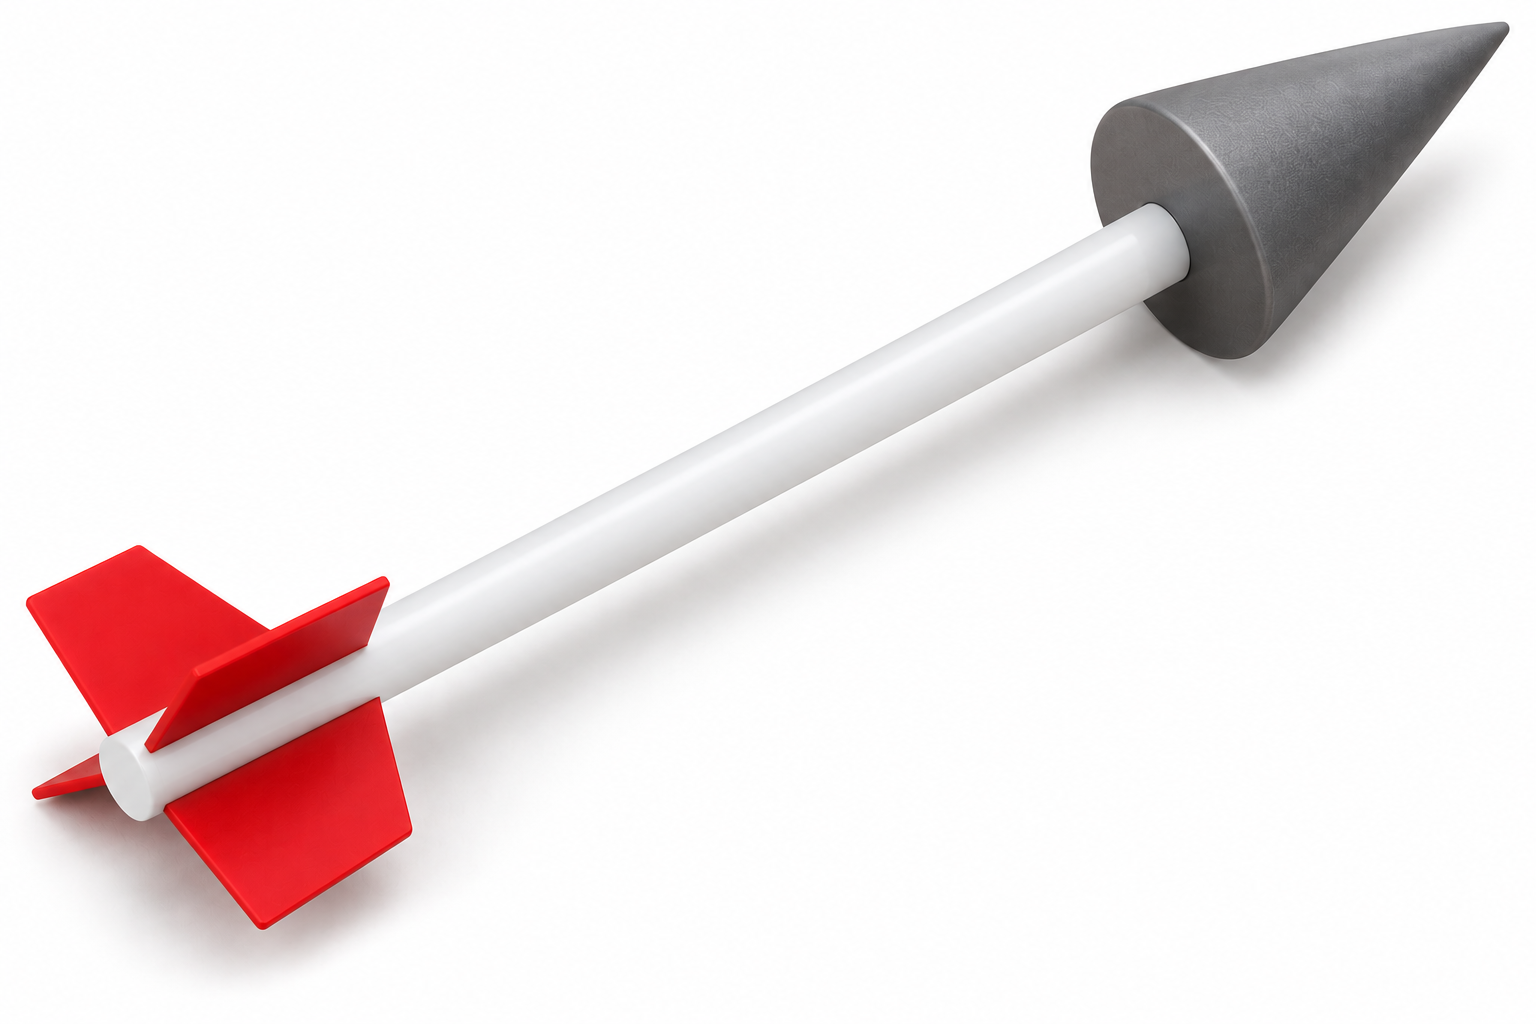
</div>



To indicate the direction of a vecor in a 2d drawing, we use circles with either a point in the center (vector pointing towards you) or a cross (vector is pointig away from you).

<div style="text-align: center;">
    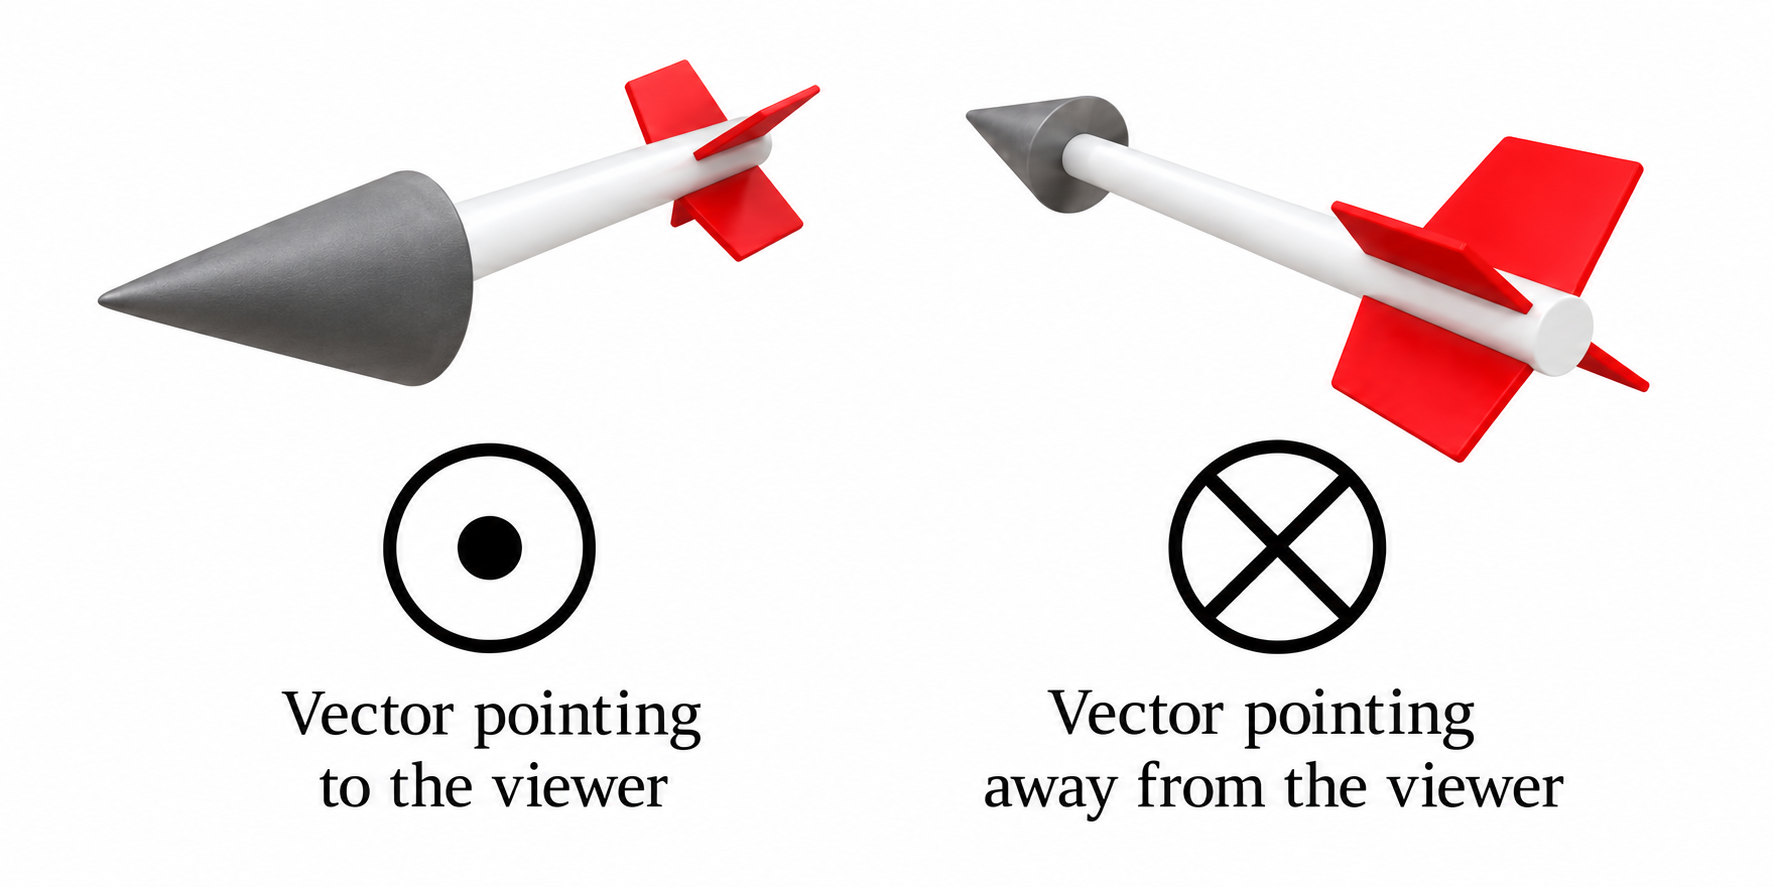
</div>


In two dimensions we write

$$
\vec a=
\begin{pmatrix}
a_x\\
a_y
\end{pmatrix}.
$$

Using unit vectors,

$$
\vec a=a_x\vec e_x+a_y\vec e_y.
$$

If the magnitude is $a$ and the direction is $\theta$,

$$
a_x=a\cos\theta,
$$

$$
a_y=a\sin\theta.
$$

Conversely,

$$
|\vec a|=\sqrt{a_x^2+a_y^2}.
$$

To determine the direction, first calculate

$$
\theta_0=\arctan\left(\frac{a_y}{a_x}\right)
$$

and then use the signs of $a_x$ and $a_y$ to determine the correct quadrant.

## Exercise 5 — Vector components

A force of magnitude

$$
F=10\,\mathrm{N}
$$

acts at an angle of $30^\circ$ above the horizontal.

Calculate $F_x$ and $F_y$.

### Exercise 6 — Magnitude and direction

A velocity vector is

$$
\vec v=
\begin{pmatrix}
3\\
4
\end{pmatrix}
\,\mathrm{m/s}.
$$

Calculate

1. its magnitude,
2. its direction relative to the positive $x$-axis.

# 4. Addition and Subtraction of Vectors

Vectors are added component by component:

$$
\vec a+\vec b
=
\begin{pmatrix}
a_x\\a_y
\end{pmatrix}
+
\begin{pmatrix}
b_x\\b_y
\end{pmatrix}
=
\begin{pmatrix}
a_x+b_x\\
a_y+b_y
\end{pmatrix}.
$$

Geometrically, vector addition can be visualized by placing the **tail of the second vector at the head of the first vector**.

Subtraction is addition of the negative vector:

$$
\vec a-\vec b=\vec a+(-\vec b).
$$

## Exercise 7 — Vector addition

Given

$$
\vec a=
\begin{pmatrix}
3\\2
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
-1\\4
\end{pmatrix},
$$

calculate

1. $\vec a+\vec b$,
2. $\vec a-\vec b$,
3. the magnitude $|\vec a+\vec b|$.

# 5. Scalar Multiplication

A vector can be multiplied by a scalar $c$:

$$
c\vec a=
\begin{pmatrix}
ca_x\\
ca_y\\
ca_z
\end{pmatrix}.
$$

This changes the magnitude of the vector. If $c<0$, it also reverses its direction.

For example,

$$
-2
\begin{pmatrix}
1\\
3
\end{pmatrix}
=
\begin{pmatrix}
-2\\
-6
\end{pmatrix}.
$$

# 6. Scalar Product (Dot Product)

For two vectors

$$
\vec a=
\begin{pmatrix}
a_x\\a_y\\a_z
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
b_x\\b_y\\b_z
\end{pmatrix},
$$

the scalar product is

$$
\boxed{
\vec a\cdot\vec b
=
a_xb_x+a_yb_y+a_zb_z
}
$$

The result is a **scalar**, not a vector.

There is also a geometric form:

$$
\boxed{
\vec a\cdot\vec b
=
|\vec a|\,|\vec b|\cos\theta
}
$$

where $\theta$ is the angle between the vectors.

Therefore, if

$$
\vec a\cdot\vec b=0,
$$

the vectors are perpendicular.

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def plot_scalar_product(angle, a, b):

    theta = np.deg2rad(angle)

    # Vector a along x-axis
    ax_a = a
    ay_a = 0

    # Vector b
    ax_b = b * np.cos(theta)
    ay_b = b * np.sin(theta)

    # Scalar product
    dot = ax_a*ax_b + ay_a*ay_b

    fig, ax = plt.subplots(figsize=(8, 6))

    # --------------------------------------------------------
    # Vectors
    # --------------------------------------------------------

    ax.arrow(
        0, 0, ax_a, ay_a,
        width=0.025,
        head_width=0.15,
        head_length=0.20,
        length_includes_head=True
    )

    ax.arrow(
        0, 0, ax_b, ay_b,
        width=0.025,
        head_width=0.15,
        head_length=0.20,
        length_includes_head=True
    )

    ax.text(
        ax_a + 0.15,
        ay_a,
        r'$\vec{a}$',
        fontsize=16
    )

    ax.text(
        ax_b + 0.15,
        ay_b + 0.10,
        r'$\vec{b}$',
        fontsize=16
    )

    # --------------------------------------------------------
    # Projection of b onto a
    # --------------------------------------------------------

    projection = b * np.cos(theta)

    ax.plot(
        [ax_b, projection],
        [ay_b, 0],
        'k--',
        lw=1
    )

    ax.plot(
        [0, projection],
        [0, 0],
        lw=5,
        alpha=0.5
    )

    ax.text(
        projection/2,
        -0.35,
        r'$|\vec b|\cos\theta$',
        ha='center'
    )

    # --------------------------------------------------------
    # Angle arc
    # --------------------------------------------------------

    r = min(a, b) * 0.25

    theta_arc = np.linspace(0, theta, 100)

    ax.plot(
        r*np.cos(theta_arc),
        r*np.sin(theta_arc),
        'k'
    )

    if angle > 0:
        ax.text(
            1.25*r*np.cos(theta/2),
            1.25*r*np.sin(theta/2),
            r'$\theta$'
        )

    # --------------------------------------------------------
    # Information
    # --------------------------------------------------------

    if abs(dot) < 1e-10:
        interpretation = "perpendicular"
    elif dot > 0:
        interpretation = "positive"
    else:
        interpretation = "negative"

    info = (
        rf"$|\vec a| = {a:.1f}$" "\n"
        rf"$|\vec b| = {b:.1f}$" "\n"
        rf"$\theta = {angle:.0f}^\circ$" "\n\n"
        rf"$\vec a\cdot\vec b"
        rf" = |\vec a||\vec b|\cos\theta$" "\n"
        rf"$= {a:.1f}\times {b:.1f}"
        rf"\times\cos({angle:.0f}^\circ)$" "\n"
        rf"$= {dot:.2f}$" "\n\n"
        rf"$\rightarrow$ {interpretation}"
    )

    ax.text(
        0.03, 0.97,
        info,
        transform=ax.transAxes,
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.9
        )
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    limit = max(a, b) + 1

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.8)

    ax.set_aspect('equal')

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

    ax.grid(alpha=0.2)

    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

angle_slider = widgets.IntSlider(
    value=45,
    min=0,
    max=180,
    step=5,
    description=r'$\theta$:',
    continuous_update=True
)

a_slider = widgets.FloatSlider(
    value=4,
    min=1,
    max=5,
    step=0.5,
    description=r'$|\vec a|$:',
    continuous_update=True
)

b_slider = widgets.FloatSlider(
    value=3,
    min=1,
    max=5,
    step=0.5,
    description=r'$|\vec b|$:',
    continuous_update=True
)

out = widgets.interactive_output(
    plot_scalar_product,
    {
        'angle': angle_slider,
        'a': a_slider,
        'b': b_slider
    }
)

controls = widgets.VBox([
    angle_slider,
    a_slider,
    b_slider
])

display(controls, out)

Output()

# Where is the scalar product used in physics?

The scalar product appears whenever we want to know **how much of one vector points in the direction of another vector**.

The central idea is the projection

$$
\vec a\cdot\vec b
=
|\vec a||\vec b|\cos\theta.
$$

This has several important applications.



## 1. Finding the angle between two vectors

If two vectors are known from their components, their angle can be calculated from

$$
\cos\theta
=
\frac{\vec a\cdot\vec b}
{|\vec a||\vec b|}.
$$

Therefore,

$$
\theta
=
\arccos
\left(
\frac{\vec a\cdot\vec b}
{|\vec a||\vec b|}
\right).
$$

---

## 2. Testing whether two vectors are perpendicular

For perpendicular vectors,

$$
\cos90^\circ=0.
$$

Therefore,

$$
\boxed{\vec a\cdot\vec b=0}
$$

is a simple test for perpendicularity.

---

## 3. Projection onto a direction

Suppose $\vec e$ is a unit vector,

$$
|\vec e|=1.
$$

Then

$$
\vec a\cdot\vec e
$$

gives the component of $\vec a$ in the direction of $\vec e$.

For example, with

$$
\vec e_x=
\begin{pmatrix}
1\\
0
\end{pmatrix},
$$

we obtain

$$
\vec a\cdot\vec e_x=a_x.
$$

Thus, vector components themselves can be understood as scalar products with the coordinate unit vectors.

## Exercise 8 — Scalar product

Given

$$
\vec a=
\begin{pmatrix}
2\\1\\0
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
1\\3\\0
\end{pmatrix},
$$

calculate

1. $\vec a\cdot\vec b$,
2. $|\vec a|$ and $|\vec b|$,
3. the angle between the vectors.

### Exercise 9 — Perpendicular vectors

Show using the scalar product that

$$
\vec a=
\begin{pmatrix}
2\\1
\end{pmatrix}
,\qquad
\vec b=
\begin{pmatrix}
-1\\2
\end{pmatrix}
$$

are perpendicular.

# 7. Vector Product (Cross Product)

The vector product of two three-dimensional vectors is

$$
\boxed{
\vec a\times\vec b
=
\begin{pmatrix}
a_yb_z-a_zb_y\\
a_zb_x-a_xb_z\\
a_xb_y-a_yb_x
\end{pmatrix}
}
$$

The result is a **vector**.

Its magnitude is

$$
|\vec a\times\vec b|
=
|\vec a|\,|\vec b|\sin\theta.
$$

The direction is perpendicular to both $\vec a$ and $\vec b$ and is determined by the **right-hand rule**.

An important geometric interpretation is:

$$
|\vec a\times\vec b|
$$

is the area of the parallelogram spanned by $\vec a$ and $\vec b$.

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def plot_cross_product(angle):

    theta = np.deg2rad(angle)

    # Two vectors in the xy-plane
    a = np.array([3.0, 0.0, 0.0])
    b = np.array([
        2.5*np.cos(theta),
        2.5*np.sin(theta),
        0.0
    ])

    # Cross product
    c = np.cross(a, b)

    # Magnitude = area of parallelogram
    area = np.linalg.norm(c)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # --------------------------------------------------------
    # Vectors a and b
    # --------------------------------------------------------

    ax.quiver(
        0, 0, 0,
        *a,
        arrow_length_ratio=0.10,
        linewidth=3
    )

    ax.quiver(
        0, 0, 0,
        *b,
        arrow_length_ratio=0.10,
        linewidth=3
    )

    # --------------------------------------------------------
    # Parallelogram
    # --------------------------------------------------------

    vertices = np.array([
        [0, 0, 0],
        a,
        a + b,
        b,
        [0, 0, 0]
    ])

    ax.plot(
        vertices[:,0],
        vertices[:,1],
        vertices[:,2],
        '--',
        lw=1.5
    )

    # --------------------------------------------------------
    # Cross-product vector
    # --------------------------------------------------------

    # Scale it slightly for visualization
    if area > 1e-10:

        c_display = c / area * 3

        ax.quiver(
            0, 0, 0,
            *c_display,
            arrow_length_ratio=0.12,
            linewidth=4
        )

        ax.text(
            c_display[0],
            c_display[1],
            c_display[2],
            r'  $\vec a\times\vec b$',
            fontsize=13
        )

    # Labels
    ax.text(
        a[0], a[1], a[2],
        r'  $\vec a$',
        fontsize=14
    )

    ax.text(
        b[0], b[1], b[2],
        r'  $\vec b$',
        fontsize=14
    )

    # --------------------------------------------------------
    # Information
    # --------------------------------------------------------

    info = (
        rf"$\theta={angle:.0f}^\circ$" "\n"
        rf"$|\vec a|=3$" "\n"
        rf"$|\vec b|=2.5$" "\n\n"
        rf"$|\vec a\times\vec b|$" "\n"
        rf"$=|\vec a||\vec b|\sin\theta$" "\n"
        rf"$={area:.2f}$"
    )

    ax.text2D(
        0.03, 0.95,
        info,
        transform=ax.transAxes,
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.9
        )
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    lim = 4

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')

    ax.set_box_aspect([1, 1, 1])

    # Fixed viewpoint
    ax.view_init(elev=25, azim=-55)

    plt.show()
    plt.close(fig)


angle_slider = widgets.IntSlider(
    value=90,
    min=0,
    max=360,
    step=5,
    description=r'$\theta$:',
    continuous_update=True
)

out = widgets.interactive_output(
    plot_cross_product,
    {'angle': angle_slider}
)

display(angle_slider, out)

IntSlider(value=90, description='$\\theta$:', max=360, step=5)

Output()

## The Right-Hand Rule

The vector product

$$
\vec c = \vec a \times \vec b
$$

produces a vector that is **perpendicular to both** $\vec a$ and $\vec b$.

There are two possible perpendicular directions. The **right-hand rule** determines the direction of the vector product.

<div style="text-align: center;">
    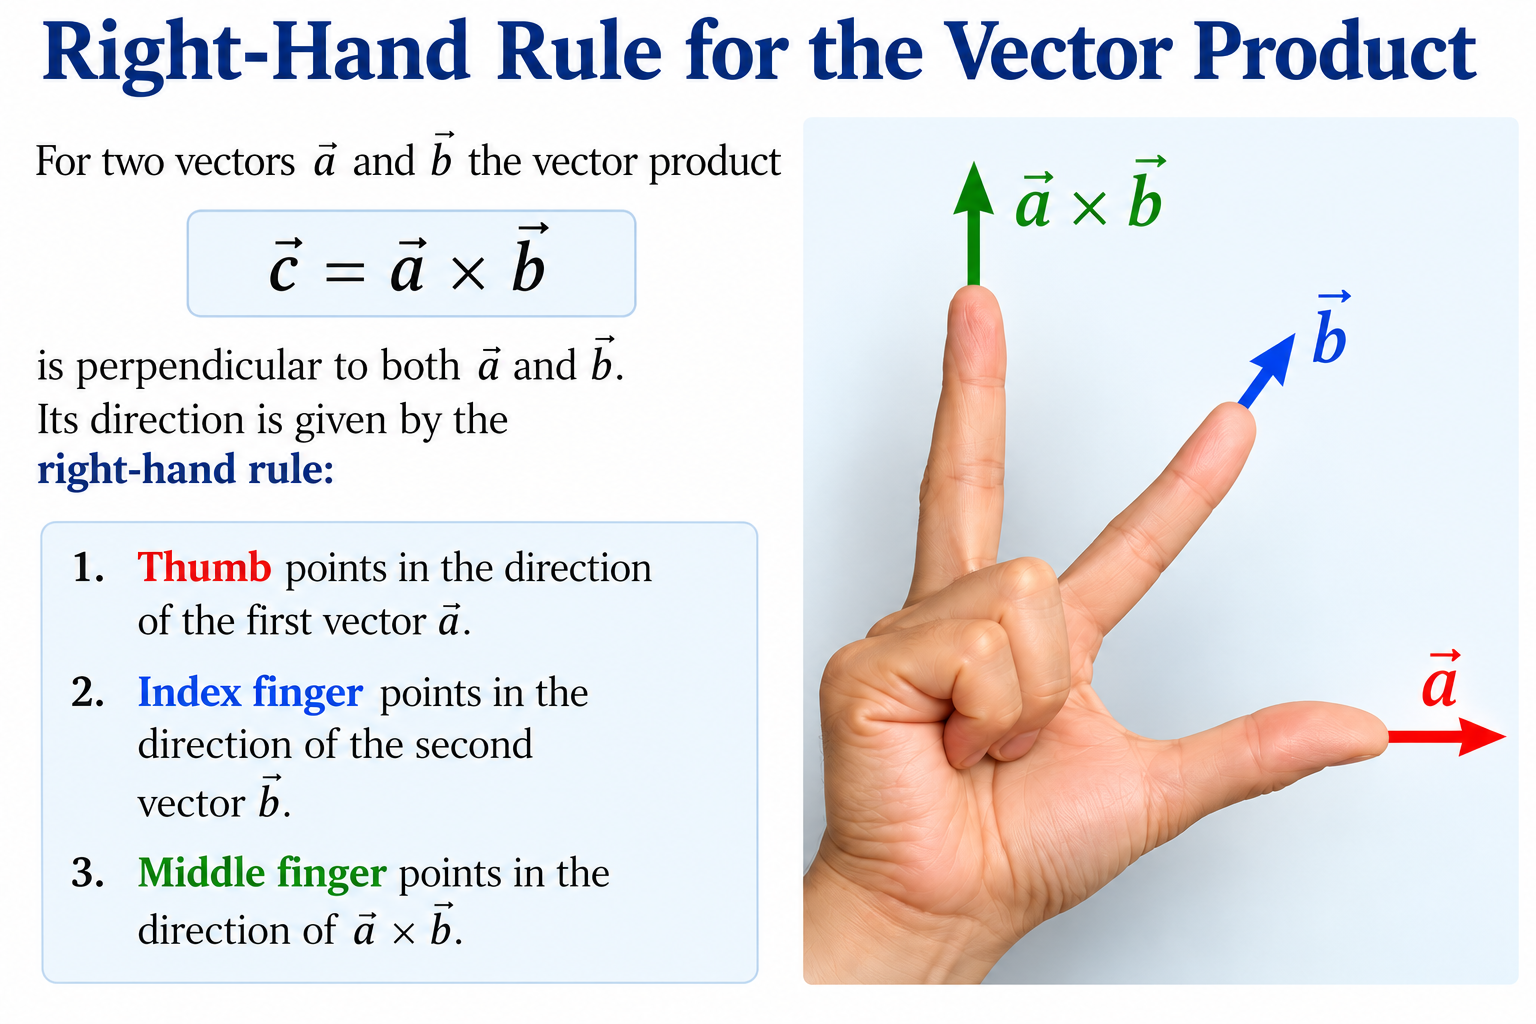
</div>



### Using the three-finger rule

Hold the **right hand** so that thumb, index finger, and middle finger point approximately perpendicular to each other:

1. **Thumb:** points in the direction of the first vector $\vec a$.
2. **Index finger:** points in the direction of the second vector $\vec b$.
3. **Middle finger:** points in the direction of the vector product $\vec a\times\vec b$.

Thus,

$$
\boxed{
\text{thumb: }\vec a,\qquad
\text{index: }\vec b,\qquad
\text{middle: }\vec a\times\vec b
}
$$

The **order is important**. Reversing the order reverses the direction:

$$
\boxed{
\vec b\times\vec a
=
-\left(\vec a\times\vec b\right)
}
$$

For the Cartesian unit vectors,

$$
\vec e_x\times\vec e_y=\vec e_z,
$$

$$
\vec e_y\times\vec e_z=\vec e_x,
$$

$$
\vec e_z\times\vec e_x=\vec e_y.
$$

Reversing any of these products changes the sign. For example,

$$
\vec e_y\times\vec e_x=-\vec e_z.
$$

## Exercise 10 — Vector product

Given

$$
\vec a=
\begin{pmatrix}
1\\0\\0
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
0\\2\\0
\end{pmatrix},
$$

calculate

$$
\vec a\times\vec b.
$$

What is its direction?

What is the area of the parallelogram spanned by the two vectors?

### Exercise 11

Calculate

$$
\vec a\times\vec b
$$

for

$$
\vec a=
\begin{pmatrix}
1\\2\\3
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
2\\0\\1
\end{pmatrix}.
$$

Verify that the result is perpendicular to both $\vec a$ and $\vec b$.

# 8. Scalar Triple Product

For three vectors $\vec a$, $\vec b$ and $\vec c$, the **scalar triple product** is

$$
\boxed{
\vec a\cdot(\vec b\times\vec c)
}
$$

The result is a scalar.

Its absolute value gives the volume of the parallelepiped spanned by the three vectors:

$$
\boxed{
V=
\left|
\vec a\cdot(\vec b\times\vec c)
\right|
}
$$

If the scalar triple product is zero, the three vectors lie in the same plane.


<div style="text-align: center;">
    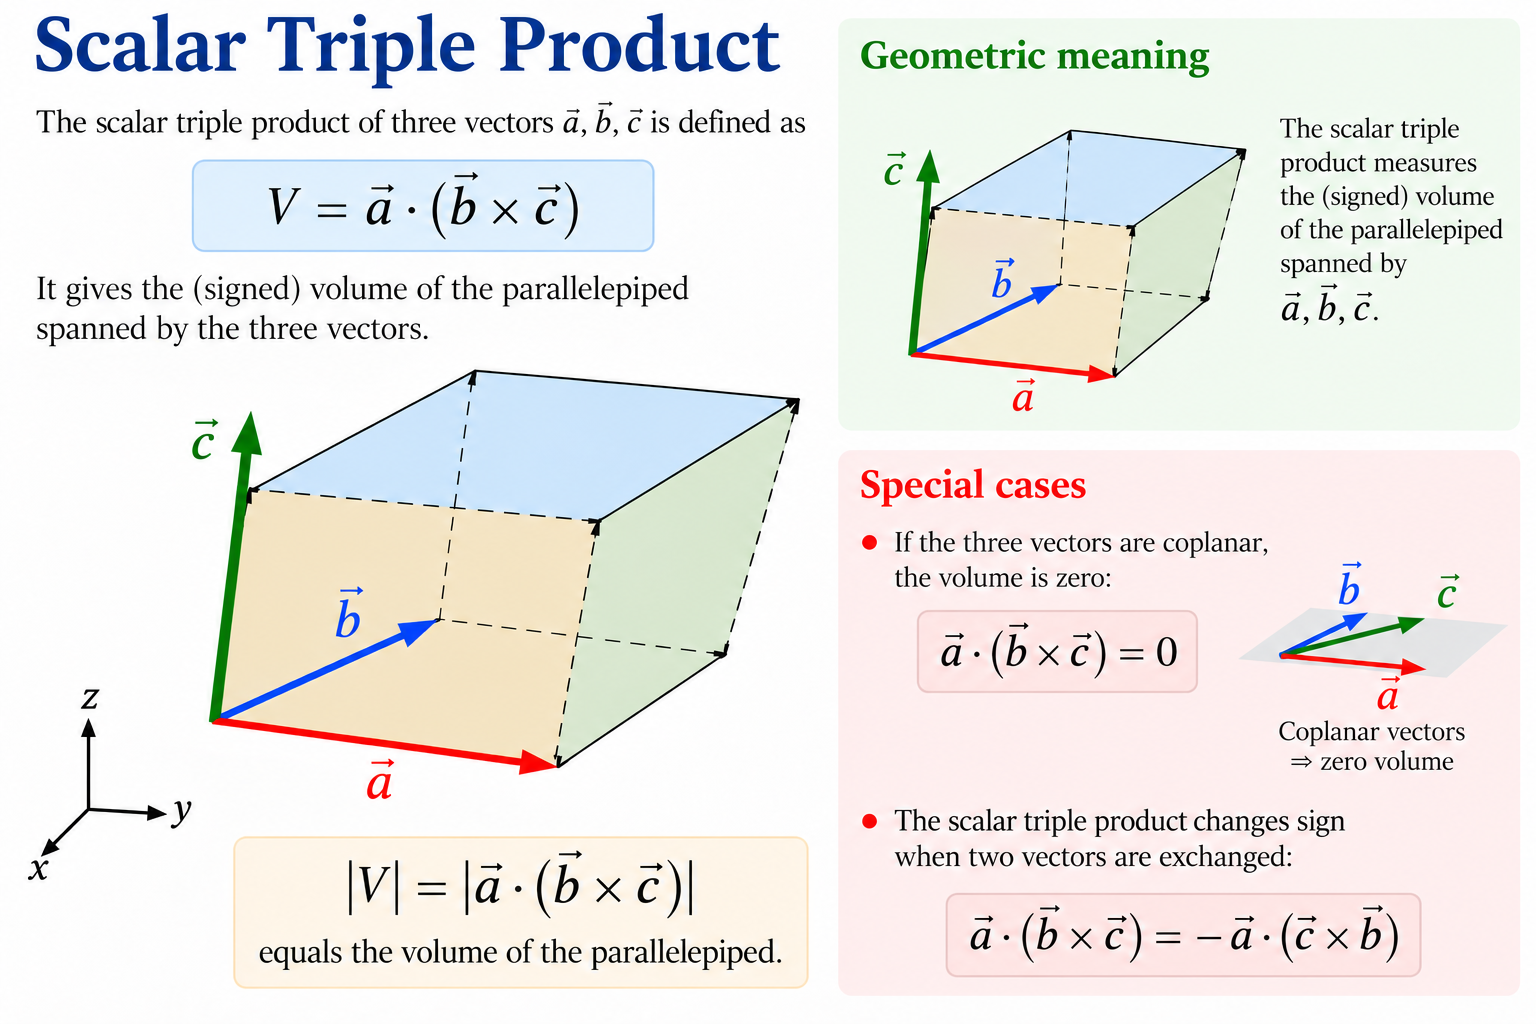
</div>


## Exercise 12 — Scalar triple product

Given

$$
\vec a=
\begin{pmatrix}
1\\0\\0
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
0\\2\\0
\end{pmatrix},
\qquad
\vec c=
\begin{pmatrix}
0\\0\\3
\end{pmatrix},
$$

calculate

$$
\vec a\cdot(\vec b\times\vec c).
$$

What is the volume of the parallelepiped?

### Exercise 13 — Coplanar vectors

Consider

$$
\vec a=
\begin{pmatrix}
1\\0\\0
\end{pmatrix},
\qquad
\vec b=
\begin{pmatrix}
0\\1\\0
\end{pmatrix},
\qquad
\vec c=
\begin{pmatrix}
2\\3\\0
\end{pmatrix}.
$$

Use the scalar triple product to show that the three vectors are coplanar.

# Summary

The most important relations are:

### Components

$$
a_x=a\cos\theta,\qquad
a_y=a\sin\theta
$$

### Magnitude

$$
|\vec a|=\sqrt{a_x^2+a_y^2+a_z^2}
$$

### Addition

$$
(\vec a+\vec b)_i=a_i+b_i
$$

### Scalar product

$$
\vec a\cdot\vec b
=
|\vec a||\vec b|\cos\theta
$$

### Vector product

$$
|\vec a\times\vec b|
=
|\vec a||\vec b|\sin\theta
$$

### Scalar triple product

$$
V=
\left|
\vec a\cdot(\vec b\times\vec c)
\right|.
$$

These operations will appear repeatedly in mechanics and other areas of physics.